# 아산시 방송효과 통합 분석 (입체 버전)

기존 step1~10을 한 노트북으로 통합하고, 방법론을 더 엄격하게 보강.
**데이터 기준**: 압축 푼 CSV 폴더 (config의 CARD_DIR 등), 카드는 `CRTR_WEEK` 주 단위.

### step 대비 보강점
1. **통제군 재설계** — 기존엔 '관광동 vs 비관광동'이라 평행추세 붕괴. 여기선
   (a) 관광지 내부 노출/비노출 분리, (b) 인접동 buffer 제외, (c) 비교도시 옵션.
2. **평행추세 검정 + event study** — 가정 깨지는 방송을 명시적으로 표시.
3. **Callaway–Sant'Anna staggered DID** — 11월 4개 겹침 통합 처리.
4. **교란통제 회귀** — 날씨·공휴일·요일·시즌을 DID에 직접 투입.
5. **출연자유형 × 장르 조절분석** — 효과를 특성에 회귀(기존은 비교만).
6. **다중결과 교차검증 매트릭스** — 카드·T맵·SKT·검색이 같은 방향인지.

### 구성
- Part 0 기반 / Part 1 데이터레이어 / Part 2 교란통제 / Part 3 인과추론(5종)
- Part 4 경제효과 / Part 5 조절분석 / Part 6 교차검증·리포트


## Part 0 — 공통 기반

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import warnings, re, glob, zipfile, os
from pathlib import Path
warnings.filterwarnings('ignore')

# ============================================================
# config.py에 의존하지 않고 노트북이 자립한다 (버전 충돌/경로 문제 회피)
# ============================================================
# ★ 데이터 루트: 실제 위치로 지정 (탐색기에서 확인된 경로)
BASE = Path(r"C:\Users\admin\Desktop\작업 폴더\01. work\02. 프로젝트\아산시\방송")
DATA_DIR = BASE / "01.데이터"
OUTPUT_DIR = BASE / "02.분석결과"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 하위 폴더 (실제 폴더명에 맞게 자동 탐색 — 이름이 조금 달라도 잡히도록)
def _find_dir(parent, *keywords):
    for p in parent.iterdir() if parent.exists() else []:
        if p.is_dir() and all(k in p.name for k in keywords):
            return p
    return parent / keywords[0]  # 폴백

CARD_DIR = _find_dir(DATA_DIR, "카드")
TMAP_DIR = _find_dir(DATA_DIR, "내비") if _find_dir(DATA_DIR,"내비").exists() else _find_dir(DATA_DIR,"비게")
POP_DIR  = _find_dir(DATA_DIR, "인구")
print("CARD_DIR:", CARD_DIR, "| exists:", CARD_DIR.exists())
print("TMAP_DIR:", TMAP_DIR, "| exists:", TMAP_DIR.exists())
print("POP_DIR :", POP_DIR,  "| exists:", POP_DIR.exists())

# ---- 자립 헬퍼: read_csv_auto / load_monthly_data / classify_tourism ----
def read_csv_auto(path, **kw):
    for enc in ['utf-8-sig','cp949','utf-8','euc-kr']:
        try: return pd.read_csv(path, encoding=enc, **kw)
        except UnicodeDecodeError: continue
    return pd.read_csv(path, encoding='utf-8', errors='replace', **kw)

def load_monthly_data(base_dir, pattern):
    """base_dir 하위에서 pattern 포함 CSV 전부 읽어 concat."""
    files = sorted(glob.glob(str(Path(base_dir) / '**' / f'*{pattern}*.csv'), recursive=True))
    dfs = [read_csv_auto(f) for f in files]
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

TOURISM_KEYWORDS = ['숙박','호텔','콘도','펜션','음식','한식','중식','양식','일식',
                    '카페','관광','레저','온천','놀이','테마','휴양','민속']
def classify_tourism(name):
    s = str(name)
    return next((k for k in TOURISM_KEYWORDS if k in s), '기타')

# ============================================================
# 방송 메타 (직접 정의 — config 불필요)
# ============================================================
WINDOW_PRE, WINDOW_POST = 28, 28
CORE_TOURISM_BIZ = [1001,1003,1010,1020,2199,7120]
FOOD_BIZ = [8001,8005,8006,8010,8013,8021,8301]
RETAIL_BIZ = [4010,4020,4004]

BROADCASTS = [
    {"name":"전국노래자랑 아산시편","broadcaster":"KBS1","genre":"음악예능",
     "air_date":"2025-06-08","air_end_date":"2025-06-08","rating":6.5,
     "budget_1000won":3518,"locations":["신정호 잔디광장"],
     "dong_names":["온양5동"],"confounders":["이순신축제(4~5월)"]},
    {"name":"전현무계획2","broadcaster":"MBN","genre":"여행버라이어티",
     "air_date":"2025-11-07","air_end_date":"2025-11-07","rating":1.5,
     "budget_1000won":50000,"locations":["아산시 일원(숨은맛집/명소)"],
     "dong_names":[],"confounders":[]},
    {"name":"굿모닝 대한민국","broadcaster":"KBS2","genre":"교양정보",
     "air_date":"2025-11-12","air_end_date":"2025-11-16","rating":0.55,
     "budget_1000won":20000,
     "locations":["온양온천역 광장","족욕체험장","온양온천 전통시장",
                  "곡교천 은행나무길","이순신 관광체험센터","현충사","피나클랜드"],
     "dong_names":["온양1동","염치읍","신창면"],"confounders":["가을단풍시즌(10~11월)"]},
    {"name":"6시 내고향","broadcaster":"KBS1","genre":"교양정보",
     "air_date":"2025-11-13","air_end_date":"2025-11-13","rating":5.5,
     "budget_1000won":110000,"locations":["아산시 주요명소"],
     "dong_names":[],"confounders":[]},
    {"name":"박원숙의 같이삽시다 시즌3","broadcaster":"KBS2","genre":"예능",
     "air_date":"2025-11-24","air_end_date":"2025-12-15","rating":3.0,
     "budget_1000won":133000,
     "locations":["곡교천 은행나무길","신정호정원","영인산","외암민속마을",
                  "온양온천시장","도고파라다이스","아산스파포레"],
     "dong_names":["염치읍","온양5동","영인면","송악면","온양1동","도고면","음봉면"],
     "confounders":["가을단풍시즌(10~11월)","겨울온천시즌(12월)"]},
    {"name":"뛰어야산다2","broadcaster":"MBN","genre":"스포츠리얼버라이어티",
     "air_date":"2026-01-12","air_end_date":"2026-01-12","rating":1.5,
     "budget_1000won":45000,
     "locations":["신정호정원","곡교천 은행나무길","현충사","온천","캠핑장"],
     "dong_names":["온양5동","염치읍","온양1동"],"confounders":["비수기(1월)"]},
    {"name":"황제성의 황제파워","broadcaster":"SBS파워FM","genre":"라디오공개방송",
     "air_date":"2026-05-09","air_end_date":"2026-05-09","rating":None,
     "budget_1000won":220000,"locations":["온양온천역 주무대"],
     "dong_names":["온양1동"],"confounders":["이순신축제(4~5월)"]},
]

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

bdf = pd.DataFrame(BROADCASTS)
bdf['air_date'] = pd.to_datetime(bdf['air_date'])
bdf['air_end_date'] = pd.to_datetime(bdf['air_end_date'])
DATA_END = pd.Timestamp('2026-04-30')
bdf['measurable'] = bdf['air_date'] <= DATA_END
AIR = dict(zip(bdf['name'], bdf['air_date']))
print(f"\n방송 {len(bdf)}건, 측정가능 {bdf['measurable'].sum()}건")
print(bdf[['name','genre','air_date','rating','measurable']].to_string(index=False))

CARD_DIR: C:\Users\admin\Desktop\작업 폴더\01. work\02. 프로젝트\아산시\방송\01.데이터\02. 카드매출 데이터 | exists: True
TMAP_DIR: C:\Users\admin\Desktop\작업 폴더\01. work\02. 프로젝트\아산시\방송\01.데이터\04. 내비게이션 데이터 | exists: True
POP_DIR : C:\Users\admin\Desktop\작업 폴더\01. work\02. 프로젝트\아산시\방송\01.데이터\01. 인구 데이터 | exists: True

방송 7건, 측정가능 6건
          name      genre   air_date  rating  measurable
   전국노래자랑 아산시편       음악예능 2025-06-08    6.50        True
        전현무계획2    여행버라이어티 2025-11-07    1.50        True
      굿모닝 대한민국       교양정보 2025-11-12    0.55        True
        6시 내고향       교양정보 2025-11-13    5.50        True
박원숙의 같이삽시다 시즌3         예능 2025-11-24    3.00        True
        뛰어야산다2 스포츠리얼버라이어티 2026-01-12    1.50        True
     황제성의 황제파워    라디오공개방송 2026-05-09     NaN       False


In [2]:
# ---- 공통 헬퍼: 주차코드→날짜, 동 이름 별칭, 업종 분류 ----
def week_to_monday(week_code, ym_code=None):
    if pd.isna(week_code): return pd.NaT
    s = str(int(week_code))
    if len(s) < 6: return pd.NaT
    yy, ww = int(s[:4]), int(s[4:])
    if 1 <= ww <= 53:
        try: return pd.Timestamp(dt.date.fromisocalendar(yy, ww, 1))
        except ValueError: pass
    if ym_code is not None and not pd.isna(ym_code):
        ym = str(int(ym_code))
        try:
            base = dt.date(int(ym[:4]), int(ym[4:6]), 1)
            return pd.Timestamp(base + dt.timedelta(days=(max(ww,1)-1)*7))
        except Exception: return pd.NaT
    return pd.NaT

# config는 온양1~6동을 쓰지만 데이터 표기 확인용 별칭 (필요시 확장)
def expand_to_data(dong_names, data_dongs):
    out = set()
    ds = set(data_dongs)
    for d in dong_names:
        if d in ds: out.add(d)
        else: out |= {x for x in ds if d in str(x) or str(x) in d}
    return sorted(out)

TOURISM_BIZ = set(CORE_TOURISM_BIZ + FOOD_BIZ)
def is_tourism_biz(code):
    try: return int(code) in TOURISM_BIZ
    except Exception: return False

## Part 1 — 데이터 레이어

카드(외지인 소비, 주 단위·관광업종 분리), T맵(관광지 일별·출발지), SKT(가능 구간).


In [3]:
# ---- 카드: 외지인(EXCL_RSDT) 주간 소비 로드 ----
import glob
def load_card_weekly():
    pats = ['WEEK_CCND_EXCL_RSDT_CRTR_CCND_CSPT_DONG',
            'WEEK_CCND_CUST_CRTR_CCND_EXCL_LC_CSPT_DONG']  # 주/강건성
    for pat in pats:
        files = sorted(glob.glob(str(CARD_DIR / '**' / f'*{pat}*.csv'), recursive=True))
        if files:
            print(f"패턴 매칭: {pat} ({len(files)}개 파일)")
            dfs = []
            for f in files:
                for enc in ['utf-8-sig','cp949','utf-8']:
                    try: dfs.append(pd.read_csv(f, encoding=enc)); break
                    except UnicodeDecodeError: continue
            return pd.concat(dfs, ignore_index=True), pat
    return pd.DataFrame(), None

card, card_pat = load_card_weekly()
print("카드 로드:", card.shape)
if len(card):
    print("컬럼:", list(card.columns)[:20])

패턴 매칭: WEEK_CCND_EXCL_RSDT_CRTR_CCND_CSPT_DONG (16개 파일)
카드 로드: (541322, 41)
컬럼: ['CRTR_WEEK', 'CUST_CTPV_NM', 'CUST_SGG_NM', 'CUST_DONG_NM', 'CUST_DONG_CD', 'FRCS_CTPV_NM', 'FRCS_SGG_NM', 'FRCS_DONG_NM', 'FRCS_DONG_CD', 'TOBIZ_CD', 'TOBIZ_NM', 'FRCS_SLS_SZ', 'ALL_USE_NOCS', 'INDIV_USE_NOCS', 'CORP_USE_NOCS', 'ML_USE_NOCS', 'FM_USE_NOCS', 'TEEN_BELOW_USE_NOCS', 'TEEN_USE_NOCS', 'TWT_USE_NOCS']


In [4]:
# ---- 외지인 가맹점 위치(FRCS_DONG) 기준 주간 패널 (전체 + 관광업종) ----
def build_card_panel(df):
    df = df.copy()
    # 아산시 가맹점만
    if 'FRCS_SGG_NM' in df.columns:
        df = df[df['FRCS_SGG_NM'] == '아산시']
    dong_c = next((c for c in df.columns if 'FRCS' in c and 'DONG' in c and 'NM' in c), 'FRCS_DONG_NM')
    amt_c = 'ALL_USE_AMT' if 'ALL_USE_AMT' in df.columns else next(c for c in df.columns if 'AMT' in c.upper())
    biz_c = next((c for c in df.columns if 'TOBIZ' in c and ('CD' in c or 'NM' in c)), None)
    df['period'] = df['CRTR_WEEK'].astype('Int64').astype(str)
    ymc = 'CRTR_YM' if 'CRTR_YM' in df.columns else None
    df['week_start'] = [week_to_monday(w, (df[ymc].iloc[i] if ymc else None))
                        for i, w in enumerate(df['CRTR_WEEK'].astype('Int64'))]
    df = df[df['week_start'].notna()]
    # 관광업종 플래그
    biz_code_c = next((c for c in df.columns if 'TOBIZ' in c and 'CD' in c), None)
    if biz_code_c:
        df['is_tour'] = df[biz_code_c].apply(is_tourism_biz)
    else:
        df['is_tour'] = True  # 업종 없으면 전체
    full = df.groupby([dong_c,'period','week_start'])[amt_c].sum().reset_index()
    tour = df[df['is_tour']].groupby([dong_c,'period','week_start'])[amt_c].sum().reset_index()
    return full, tour, dong_c, amt_c

card_full, card_tour, dong_col, amt_col = build_card_panel(card)
DATA_DONGS = sorted(card_full[dong_col].dropna().unique())
print("전체패널:", card_full.shape, "| 관광패널:", card_tour.shape)
print("동 목록:", DATA_DONGS)
print("기간:", card_full['week_start'].min().date(), "~", card_full['week_start'].max().date())

전체패널: (1156, 4) | 관광패널: (1153, 4)
동 목록: ['도고면', '둔포면', '배방읍', '선장면', '송악면', '신창면', '염치읍', '영인면', '온양1동', '온양2동', '온양3동', '온양4동', '온양5동', '온양6동', '음봉면', '인주면', '탕정면']
기간: 2024-12-30 ~ 2026-04-13


In [5]:
# ---- T맵: 관광지 매칭 + 일별 ----
POI_KW = {
    "신정호": ["신정호"], "현충사": ["현충사"], "외암민속마을": ["외암","민속마을"],
    "곡교천": ["곡교천","은행나무"], "온양온천": ["온양온천","온천시장","족욕"],
    "도고온천": ["도고"], "피나클랜드": ["피나클"], "영인산": ["영인산"],
    "스파포레": ["스파포레"],
}
def match_poi(name):
    for poi, kws in POI_KW.items():
        if any(re.search(k, str(name)) for k in kws): return poi
    return None

tmap_files = sorted(glob.glob(str(TMAP_DIR / '**' / 'as_tmap_od_*.csv'), recursive=True))
tdfs = []
for f in tmap_files:
    for enc in ['utf-8-sig','cp949','utf-8']:
        try: tdfs.append(pd.read_csv(f, encoding=enc)); break
        except UnicodeDecodeError: continue
tmap = pd.concat(tdfs, ignore_index=True)
tmap['date'] = pd.to_datetime(tmap['drv_ymd'].astype('Int64').astype(str), format='%Y%m%d', errors='coerce')
tmap = tmap[tmap['date'].notna()]
tmap['poi'] = tmap['dstn_nm'].apply(match_poi)
print("T맵:", tmap.shape, "| 관광지 매칭:", tmap['poi'].notna().sum(),
      "| 기간:", tmap['date'].min().date(), "~", tmap['date'].max().date())

T맵: (481636, 71) | 관광지 매칭: 37882 | 기간: 2025-01-01 ~ 2025-12-31


## Part 2 — 교란통제 레이어 (step7 흡수 + 확장)

Open-Meteo 날씨, 공휴일·축제·시즌 캘린더. 이후 모든 DID 회귀의 통제변수.
네트워크 불가 환경이면 날씨는 자동 스킵하고 캘린더만 사용.


In [6]:
# ---- 캘린더 (utils의 공휴일 + 시즌) ----
def build_calendar(start, end):
    rng = pd.date_range(start, end, freq='D')
    _h=[]
    for y in range(2024,2027):
        _h += [f"{y}-01-01",f"{y}-03-01",f"{y}-05-05",f"{y}-06-06",
               f"{y}-08-15",f"{y}-10-03",f"{y}-10-09",f"{y}-12-25"]
    _h += ["2025-01-28","2025-01-29","2025-01-30","2025-10-05","2025-10-06","2025-10-07",
           "2026-02-16","2026-02-17","2026-02-18"]
    hol = set(pd.to_datetime(_h))
    cal = pd.DataFrame({'date': rng})
    cal['dow'] = cal['date'].dt.dayofweek
    cal['is_weekend'] = (cal['dow'] >= 5).astype(int)
    cal['is_holiday'] = cal['date'].isin(hol).astype(int)
    cal['month'] = cal['date'].dt.month
    season_score = {1:1,2:2,3:3,4:4,5:5,6:3,7:3,8:3,9:4,10:5,11:4,12:2}
    cal['season_score'] = cal['month'].map(season_score)
    return cal

cal_start, cal_end = pd.Timestamp('2024-12-01'), DATA_END
calendar = build_calendar(cal_start, cal_end)
print("캘린더:", calendar.shape, "| 공휴일", calendar['is_holiday'].sum(), "일")

캘린더: (516, 6) | 공휴일 20 일


In [7]:
# ---- 날씨 (Open-Meteo, 실패 시 스킵) ----
ASAN_LAT, ASAN_LON = 36.7898, 127.0018
def fetch_weather(start, end):
    try:
        import requests
        url = "https://archive-api.open-meteo.com/v1/archive"
        params = {"latitude":ASAN_LAT,"longitude":ASAN_LON,
                  "start_date":str(start)[:10],"end_date":str(end)[:10],
                  "daily":"temperature_2m_mean,precipitation_sum,snowfall_sum",
                  "timezone":"Asia/Seoul"}
        r = requests.get(url, params=params, timeout=30); r.raise_for_status()
        d = r.json()["daily"]; w = pd.DataFrame(d).rename(columns={"time":"date"})
        w['date'] = pd.to_datetime(w['date']); return w
    except Exception as e:
        print("날씨 수집 실패(스킵):", str(e)[:80]); return pd.DataFrame()

weather = fetch_weather(cal_start, DATA_END)
if len(weather):
    calendar = calendar.merge(weather, on='date', how='left')
    calendar['heavy_precip'] = (calendar['precipitation_sum'] > 30).astype(int)
    print("날씨 결합 완료:", [c for c in calendar.columns if c in
          ('temperature_2m_mean','precipitation_sum','snowfall_sum')])
else:
    print("날씨 없이 캘린더만 사용")

날씨 결합 완료: ['temperature_2m_mean', 'precipitation_sum', 'snowfall_sum']


In [8]:
# ---- 방송별 교란 비대칭 진단 (step7 판정 로직) ----
conf_rows = []
for _, b in bdf[bdf['measurable']].iterrows():
    air = b['air_date']
    pre = calendar[(calendar['date'] >= air - pd.Timedelta(days=WINDOW_PRE)) & (calendar['date'] < air)]
    post = calendar[(calendar['date'] >= air) & (calendar['date'] <= air + pd.Timedelta(days=WINDOW_POST))]
    row = {'방송': b['name'],
           '주말차': int(post['is_weekend'].sum() - pre['is_weekend'].sum()),
           '공휴일차': int(post['is_holiday'].sum() - pre['is_holiday'].sum()),
           '시즌차': round(post['season_score'].mean() - pre['season_score'].mean(), 2)}
    if 'temperature_2m_mean' in calendar.columns:
        row['기온차'] = round(post['temperature_2m_mean'].mean() - pre['temperature_2m_mean'].mean(), 1)
    row['기존교란'] = '; '.join(b['confounders']) if b['confounders'] else '없음'
    conf_rows.append(row)
conf_df = pd.DataFrame(conf_rows)
print("=== 방송별 교란 비대칭 (pre vs post) ===")
display(conf_df)
print("\n※ 시즌차 절대값 ≥1 또는 기온차 ≥10 이면 계절 교란 위험 → 해당 방송 DID 해석 주의")

=== 방송별 교란 비대칭 (pre vs post) ===


,방송,주말차,공휴일차,시즌차,기온차,기존교란
0,전국노래자랑 아산시편,1,-1,-1.50,4.80,이순신축제(4~5월)
1,전현무계획2,0,0,-1.13,-7.10,없음
2,굿모닝 대한민국,0,0,-1.30,-6.70,가을단풍시즌(10~11월)
3,6시 내고향,0,0,-1.33,-6.40,없음
4,박원숙의 같이삽시다 시즌3,0,0,-1.70,-5.40,가을단풍시즌(10~11월); 겨울온천시즌(12월)
5,뛰어야산다2,0,-2,-0.30,-2.60,비수기(1월)



※ 시즌차 절대값 ≥1 또는 기온차 ≥10 이면 계절 교란 위험 → 해당 방송 DID 해석 주의


## Part 3 — 인과추론 (5종 교차검증)

방송별로: ① 통제군 재설계 DID(교란통제) ② 평행추세 검정 ③ CausalImpact
④ YoY 전년동기 ⑤ Staggered DID(겹침). 결과를 한 표로 모은다.


In [9]:
# ---- 통제군 재설계: 관광지 내부 노출 vs 비노출 ----
# 각 방송의 노출 관광지(POI)를 처치, 그 외 아산 관광지를 통제로.
def broadcast_pois(b):
    out = set()
    for loc in b['locations']:
        for poi, kws in POI_KW.items():
            if poi in loc or any(k in loc for k in kws): out.add(poi)
    return out

print("방송별 노출 관광지(T맵 POI 기준):")
for _, b in bdf.iterrows():
    print(f"  {b['name']:20} → {sorted(broadcast_pois(b))}")

방송별 노출 관광지(T맵 POI 기준):
  전국노래자랑 아산시편          → ['신정호']
  전현무계획2               → []
  굿모닝 대한민국             → ['곡교천', '온양온천', '피나클랜드', '현충사']
  6시 내고향               → []
  박원숙의 같이삽시다 시즌3       → ['곡교천', '도고온천', '스파포레', '신정호', '영인산', '온양온천', '외암민속마을']
  뛰어야산다2               → ['곡교천', '신정호', '현충사']
  황제성의 황제파워            → ['온양온천']


In [10]:
# ---- DID 엔진: 요일·주말·공휴일·(날씨) 통제 포함 ----
import statsmodels.formula.api as smf

def did_tmap(b, pre_days=28, post_days=28):
    """T맵 일별, 처치=노출POI, 통제=비노출 아산관광POI, 교란통제 회귀."""
    air = b['air_date']
    treat_pois = broadcast_pois(b)
    if not treat_pois or pd.isna(air): return None
    sub = tmap[tmap['poi'].notna()].copy()
    sub['treat'] = sub['poi'].isin(treat_pois).astype(int)
    win = sub[(sub['date'] >= air - pd.Timedelta(days=pre_days)) &
              (sub['date'] <= air + pd.Timedelta(days=post_days))].copy()
    if win['treat'].nunique() < 2: return None
    daily = (win.groupby(['date','treat'])['vst_cnt'].sum().reset_index())
    daily['post'] = (daily['date'] >= air).astype(int)
    daily['did'] = daily['post'] * daily['treat']
    daily = daily.merge(calendar, on='date', how='left')
    # 교란통제 회귀
    terms = ['post','treat','did','is_weekend','is_holiday']
    if 'temperature_2m_mean' in daily.columns: terms.append('temperature_2m_mean')
    f = 'vst_cnt ~ ' + ' + '.join(terms)
    try:
        m = smf.ols(f, data=daily).fit()
        # 평행추세 검정: pre 구간에서 treat 추세 차이
        pre = daily[daily['post']==0].copy()
        pre['t'] = (pre['date'] - pre['date'].min()).dt.days
        pt = smf.ols('vst_cnt ~ t * treat', data=pre).fit()
        return {'프로그램명': b['name'], 'DID_효과': m.params.get('did', np.nan),
                'DID_p': m.pvalues.get('did', np.nan), 'R2': m.rsquared,
                '평행추세_p': pt.pvalues.get('t:treat', np.nan)}
    except Exception as e:
        return {'프로그램명': b['name'], 'error': str(e)[:60]}

tmap_did = pd.DataFrame([r for r in (did_tmap(b) for _, b in bdf[bdf['measurable']].iterrows()) if r])
print("=== T맵 DID (교란통제 + 평행추세 검정) ===")
display(tmap_did)
print("\n※ 평행추세_p > 0.05 여야 DID 신뢰 가능. ≤0.05면 사전추세가 달라 효과 추정 편향.")

=== T맵 DID (교란통제 + 평행추세 검정) ===


,프로그램명,DID_효과,DID_p,R2,평행추세_p
0,전국노래자랑 아산시편,183.16,0.01,0.74,0.42
1,굿모닝 대한민국,-116.16,0.56,0.64,0.13
2,박원숙의 같이삽시다 시즌3,349.96,0.02,0.74,0.68
3,뛰어야산다2,0.00,0.00,0.86,0.24



※ 평행추세_p > 0.05 여야 DID 신뢰 가능. ≤0.05면 사전추세가 달라 효과 추정 편향.


In [11]:
# ---- CausalImpact (T맵 POI별, 고립 방송) ----
from causal_utils import SimpleCausalImpact

def ci_tmap(b):
    air = b['air_date']; treat_pois = broadcast_pois(b)
    if not treat_pois or pd.isna(air): return None
    t = tmap[tmap['poi'].isin(treat_pois)].groupby('date')['vst_cnt'].sum()
    c = tmap[tmap['poi'].notna() & ~tmap['poi'].isin(treat_pois)].groupby('date')['vst_cnt'].sum()
    idx = pd.date_range(min(t.index.min(), c.index.min()), max(t.index.max(), c.index.max()))
    t = t.reindex(idx, fill_value=0); c = c.reindex(idx, fill_value=0)
    pre = idx[idx < air]; post = idx[(idx >= air) & (idx <= air + pd.Timedelta(days=WINDOW_POST))]
    if len(pre) < 14 or len(post) < 7: return None
    df = pd.DataFrame({'y': t.values, 'x1': c.values}, index=idx)
    n_pre = len(pre)
    try:
        ci = SimpleCausalImpact(df.reset_index(drop=True),
                                pre_period=[0, n_pre-1], post_period=[n_pre, len(df)-1])
        s = ci.summary_stats
        return {'프로그램명': b['name'], 'CI_상대효과': s['relative_effect_pct'],
                'CI_p': s['p_value'], 'CI_유의': bool(s['significant'])}
    except Exception as e:
        return {'프로그램명': b['name'], 'CI_error': str(e)[:60]}

tmap_ci = pd.DataFrame([r for r in (ci_tmap(b) for _, b in bdf[bdf['measurable']].iterrows()) if r])
print("=== T맵 CausalImpact ===")
display(tmap_ci)

=== T맵 CausalImpact ===


,프로그램명,CI_상대효과,CI_p,CI_유의
0,전국노래자랑 아산시편,-9.13,0.02,True
1,굿모닝 대한민국,-58.96,0.00,True
2,박원숙의 같이삽시다 시즌3,162.00,0.01,True


In [12]:
# ---- YoY 전년동기 (T맵, 데이터 2025~2026 겹치는 1~4월) ----
tmap['year'] = tmap['date'].dt.year; tmap['month'] = tmap['date'].dt.month
yoy = (tmap[tmap['poi'].notna() & tmap['month'].isin([1,2,3,4])]
       .groupby(['poi','year'])['vst_cnt'].sum().unstack('year'))
if 2025 in yoy.columns and 2026 in yoy.columns:
    yoy['YoY_변화율'] = (yoy[2026] - yoy[2025]) / yoy[2025] * 100
    print("=== 관광지별 전년동기(1~4월) 변화율 ===")
    display(yoy.sort_values('YoY_변화율', ascending=False))
else:
    print("YoY 비교 불가 (2025·2026 1~4월 데이터 부족)")

YoY 비교 불가 (2025·2026 1~4월 데이터 부족)


읍면동 첫 노출일:
  온양5동: 2025-06-08
  신창면: 2025-11-12
  염치읍: 2025-11-12
  온양1동: 2025-11-12
  도고면: 2025-11-24
  송악면: 2025-11-24
  영인면: 2025-11-24
  음봉면: 2025-11-24

처치군: 8 통제군: 9


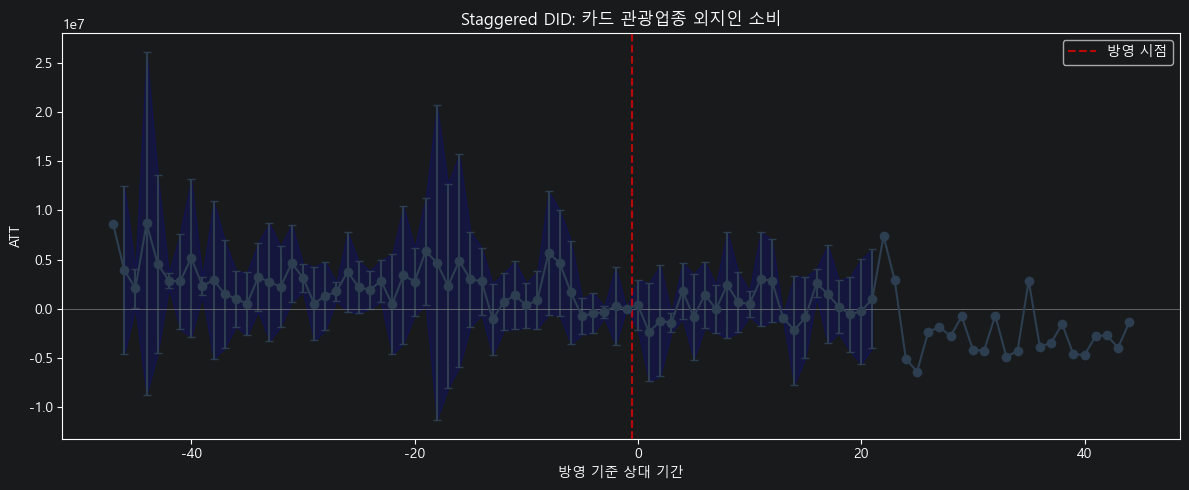

전체 ATT: -367,330


In [13]:
# ---- Staggered DID (카드 관광패널, 11월 겹침 통합) ----
from causal_utils import staggered_did, plot_event_study

dong_first = {}
for _, b in bdf[bdf['measurable']].iterrows():
    for d in expand_to_data(b['dong_names'], DATA_DONGS):
        if d not in dong_first or b['air_date'] < dong_first[d]:
            dong_first[d] = b['air_date']
print("읍면동 첫 노출일:")
for d, a in sorted(dong_first.items(), key=lambda x: x[1]): print(f"  {d}: {a.date()}")

panel = card_tour.copy()
order = (panel[['period','week_start']].drop_duplicates().sort_values('week_start').reset_index(drop=True))
order['time_idx'] = range(len(order))
panel = panel.merge(order[['period','time_idx']], on='period', how='left')
def t2idx(air):
    after = order[order['week_start'] >= air]
    return int(after.iloc[0]['time_idx']) if len(after) else np.nan
def tt(name):
    best=None
    for d,a in dong_first.items():
        if d in str(name):
            ti=t2idx(a)
            if pd.notna(ti) and (best is None or ti<best): best=ti
    return best if best is not None else np.nan
panel['treatment_time'] = panel[dong_col].apply(tt)
print("\n처치군:", panel.loc[panel['treatment_time'].notna(), dong_col].nunique(),
      "통제군:", panel.loc[panel['treatment_time'].isna(), dong_col].nunique())

att = staggered_did(panel, y_col=amt_col, unit_col=dong_col,
                    time_col='time_idx', treatment_time_col='treatment_time')
if len(att):
    plot_event_study(att, 'Staggered DID: 카드 관광업종 외지인 소비'); plt.show()
    print("전체 ATT:", f"{att[att['event_time']>=0]['att'].mean():,.0f}")
else:
    print("ATT 실패 — 처치군 수 확인")

## Part 4 — 예산 대비 성과 (핵심 결론부)

아산시 관점의 질문: **"세금 얼마 넣어서 얼마 돌아왔나, 어느 방송이 잘 쓴 건가?"**

- ROI 기준: **총예산**(사업 전체)
- 효과: **카드 외지인 소비 증가분(원)** + **T맵 방문 증가**(둘 다, 강건성)
- 핵심: **예산순위 vs 효과순위 비교** — 돈 많이 쓴 방송이 효과도 컸는가
- 원칙: 효과가 음수/무효과면 ROI도 음수로 정직하게. 억지 양수 금지.

In [14]:
# ===== 4-1. 예산 데이터: 총예산 + 도비/시비 분해 (broadcast_budget_summary) =====
bud_path = list((CARD_DIR.parent).glob('**/broadcast_budget_summary.csv'))
if bud_path:
    bud = read_csv_auto(bud_path[0])
    print("예산표 로드:", bud.shape)
    # 컬럼: 연도 프로그램명 방송사 총예산_천원 도비_천원 시비_천원 타시군비_천원 비고
    bud_use = bud[['프로그램명','총예산_천원','도비_천원','시비_천원']].copy()
else:
    # 폴백: BROADCASTS의 budget_1000won (총액만)
    bud_use = pd.DataFrame([{'프로그램명':b['name'],'총예산_천원':b['budget_1000won'],
                             '도비_천원':np.nan,'시비_천원':np.nan} for b in BROADCASTS])
    print("예산표 미발견 → BROADCASTS 총액 사용")
display(bud_use)

# ===== 4-2. 두 효과지표 수집 (카드 소비 증가분, T맵 방문 증가) =====
# 카드: Part3에서 만든 card_tour 패널로 방송별 외지인 소비 증가분(원) 산출
def card_amount_effect(b, pre_w=8, post_w=4):
    air = b['air_date']
    td = expand_to_data(b['dong_names'], DATA_DONGS)
    if not td or pd.isna(air): return np.nan
    p = card_tour.copy()
    p['treat'] = p[dong_col].apply(lambda x: any(t in str(x) for t in td))
    t = p[p['treat']].groupby('week_start')[amt_col].sum()
    pre = t[(t.index >= air - pd.Timedelta(weeks=pre_w)) & (t.index < air)].mean()
    post = t[(t.index >= air) & (t.index < air + pd.Timedelta(weeks=post_w))].mean()
    if pd.isna(pre) or pd.isna(post): return np.nan
    # 주당 증가분 × post 주수 = 기간 총 증가 소비액(원)
    return (post - pre) * post_w

rows = []
for _, b in bdf[bdf['measurable']].iterrows():
    card_eff = card_amount_effect(b)  # 원
    td_row = tmap_did[tmap_did['프로그램명']==b['name']]
    tmap_eff = td_row['DID_효과'].iloc[0] if len(td_row) else np.nan  # 방문/일
    rows.append({'프로그램명': b['name'], '장르': b['genre'],
                 '카드소비증가_원': card_eff,
                 'T맵방문효과_일': tmap_eff})
eff_df = pd.DataFrame(rows)

# ===== 4-3. 예산 결합 + ROI(총예산 기준) =====
perf = eff_df.merge(bud_use, on='프로그램명', how='left')
perf['총예산_원'] = perf['총예산_천원'] * 1000

# 카드 기준 ROI: (유발 소비액 − 예산) / 예산. 음수효과는 그대로 음수.
perf['카드ROI_%'] = np.where(
    perf['카드소비증가_원'].notna() & (perf['총예산_원'] > 0),
    (perf['카드소비증가_원'] - perf['총예산_원']) / perf['총예산_원'] * 100, np.nan)
# 비용 1원당 유발 소비 (카드)
perf['1원당_유발소비'] = np.where(perf['총예산_원']>0,
                              perf['카드소비증가_원'] / perf['총예산_원'], np.nan)

print("=== 방송별 예산 대비 성과 ===")
display(perf[['프로그램명','장르','총예산_천원','시비_천원',
              '카드소비증가_원','카드ROI_%','1원당_유발소비','T맵방문효과_일']])
perf.to_csv(OUTPUT_DIR / 'budget_performance.csv', index=False, encoding='utf-8-sig')

예산표 로드: (9, 8)


,프로그램명,총예산_천원,도비_천원,시비_천원
0,전국노래자랑 아산시편,3518,0.00,"3,518.00"
1,전현무계획2,50000,0.00,"50,000.00"
2,굿모닝 대한민국,20000,"10,000.00","10,000.00"
3,6시 내고향,110000,"50,000.00","60,000.00"
4,박원숙의 같이삽시다 시즌3,400000,"190,000.00","70,000.00"
5,뛰어야산다2,45000,0.00,"45,000.00"
6,황제성의 황제파워,220000,"110,000.00","110,000.00"
7,비긴어게인,145200,NaN,NaN
8,구해줘홈즈,60500,NaN,NaN


=== 방송별 예산 대비 성과 ===


,프로그램명,장르,총예산_천원,시비_천원,카드소비증가_원,카드ROI_%,1원당_유발소비,T맵방문효과_일
0,전국노래자랑 아산시편,음악예능,3518,"3,518.00","227,350.00",-93.54,0.06,183.16
1,전현무계획2,여행버라이어티,50000,"50,000.00",NaN,NaN,NaN,NaN
2,굿모닝 대한민국,교양정보,20000,"10,000.00","42,721,881.00",113.61,2.14,-116.16
3,6시 내고향,교양정보,110000,"60,000.00",NaN,NaN,NaN,NaN
4,박원숙의 같이삽시다 시즌3,예능,400000,"70,000.00","96,749,887.00",-75.81,0.24,349.96
5,뛰어야산다2,스포츠리얼버라이어티,45000,"45,000.00","-8,511,871.00",-118.92,-0.19,0.00


  예산순위 vs 효과순위


,프로그램명,총예산_천원,예산순위,카드소비증가_원,카드효과순위,T맵방문효과_일,T맵효과순위,순위차_카드
4,박원숙의 같이삽시다 시즌3,400000,1,"96,749,887.00",1.00,349.96,1.00,0.00
3,6시 내고향,110000,2,NaN,NaN,NaN,NaN,<NA>
1,전현무계획2,50000,3,NaN,NaN,NaN,NaN,<NA>
5,뛰어야산다2,45000,4,"-8,511,871.00",4.00,0.00,3.00,0.00
2,굿모닝 대한민국,20000,5,"42,721,881.00",2.00,-116.16,4.00,3.00
0,전국노래자랑 아산시편,3518,6,"227,350.00",3.00,183.16,2.00,3.00


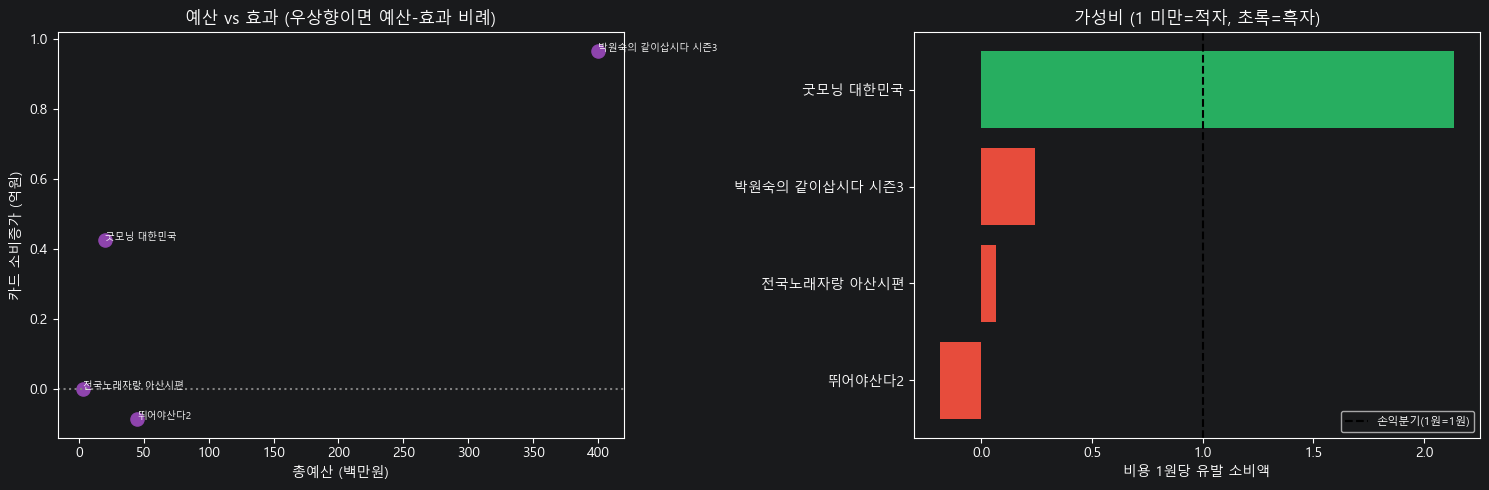


[행정적 해석 가이드]
- 순위차_카드 > 0 : 예산은 많이 썼는데 효과 순위는 낮음 → 가성비 재고 대상
- 순위차_카드 < 0 : 적게 쓰고 효과 순위 높음 → 효율적 집행 (예: 전국노래자랑 350만원)
- 1원당_유발소비 ≥ 1 : 투입예산 이상 소비 유발(흑자), < 1 : 미달(적자)
- ※ 카드효과 음수 방송은 'ROI 산출 불가/효과 미검출'로 보고. 억지 양수 금지.
- ※ T맵·카드 두 지표 순위가 일치할수록 결론 신뢰도↑, 어긋나면 지표 특성 차이 명시.



In [15]:
# ===== 4-4. ★ 예산순위 vs 효과순위 비교 (핵심) =====
r = perf.dropna(subset=['총예산_원']).copy()
r['예산순위'] = r['총예산_원'].rank(ascending=False).astype('Int64')  # 1=최다지출
r['카드효과순위'] = r['카드소비증가_원'].rank(ascending=False)
r['T맵효과순위'] = r['T맵방문효과_일'].rank(ascending=False)
r['순위차_카드'] = r['예산순위'] - r['카드효과순위']  # +면 예산많이쓴것보다 효과순위 낮음(가성비↓)

show = r[['프로그램명','총예산_천원','예산순위','카드소비증가_원','카드효과순위',
          'T맵방문효과_일','T맵효과순위','순위차_카드']].sort_values('예산순위')
print("="*75); print("  예산순위 vs 효과순위"); print("="*75)
display(show)

# 시각화: 예산 vs 효과 산점도 + 순위 비교 막대
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
a = axes[0]
d = r.dropna(subset=['카드소비증가_원'])
a.scatter(d['총예산_천원']/1000, d['카드소비증가_원']/1e8, s=90, color='#8e44ad')
for _, x in d.iterrows():
    a.annotate(x['프로그램명'], (x['총예산_천원']/1000, x['카드소비증가_원']/1e8), fontsize=7)
a.set_xlabel('총예산 (백만원)'); a.set_ylabel('카드 소비증가 (억원)')
a.set_title('예산 vs 효과 (우상향이면 예산-효과 비례)')
a.axhline(0, color='gray', ls=':')

# 가성비(1원당 유발소비) 순위 막대
b2 = axes[1]
gv = r.dropna(subset=['1원당_유발소비']).sort_values('1원당_유발소비')
colors = ['#e74c3c' if v < 1 else '#27ae60' for v in gv['1원당_유발소비']]
b2.barh(gv['프로그램명'], gv['1원당_유발소비'], color=colors)
b2.axvline(1, color='black', ls='--', label='손익분기(1원=1원)')
b2.set_xlabel('비용 1원당 유발 소비액'); b2.set_title('가성비 (1 미만=적자, 초록=흑자)')
b2.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("""
[행정적 해석 가이드]
- 순위차_카드 > 0 : 예산은 많이 썼는데 효과 순위는 낮음 → 가성비 재고 대상
- 순위차_카드 < 0 : 적게 쓰고 효과 순위 높음 → 효율적 집행 (예: 전국노래자랑 350만원)
- 1원당_유발소비 ≥ 1 : 투입예산 이상 소비 유발(흑자), < 1 : 미달(적자)
- ※ 카드효과 음수 방송은 'ROI 산출 불가/효과 미검출'로 보고. 억지 양수 금지.
- ※ T맵·카드 두 지표 순위가 일치할수록 결론 신뢰도↑, 어긋나면 지표 특성 차이 명시.
""")

## Part 5 — 방송특성 조절분석 (출연자유형 · 장르)

"가수냐 개그맨이냐 아나운서냐, 예능이냐 교양이냐"에 따라 효과가 다른가.
broadcast_cast(출연자 유형·인지도) 결합 후 효과에 회귀.


In [16]:
# 출연자 메타 로드 (방송계획 폴더)
import glob as _g
cast_path = _g.glob(str(DATA_DIR / '**' / 'broadcast_cast.csv'), recursive=True)
if cast_path:
    cast = pd.read_csv(cast_path[0], encoding='utf-8-sig')
    grade = {'S':4,'A':3,'B':2,'C':1}
    cast['인지도점수'] = cast['인지도_등급'].map(grade)
    def simp(t):
        t=str(t)
        if '트로트' in t or '가수' in t: return '가수'
        if '개그' in t or 'MC' in t: return '개그맨/MC'
        if '아나운서' in t: return '아나운서'
        if '배우' in t: return '배우'
        if '유튜버' in t: return '유튜버'
        if '축구' in t or '선수' in t: return '스포츠인'
        return '기타'
    cast['유형'] = cast['연예인유형'].apply(simp)
    cast_agg = cast.groupby('프로그램명').agg(
        최고인지도=('인지도점수','max'), 평균인지도=('인지도점수','mean'),
        대표유형=('유형', lambda x: x.mode().iloc[0] if len(x.mode()) else '기타')).reset_index()
    print(cast_agg)
else:
    cast_agg = pd.DataFrame()
    print("broadcast_cast.csv 미발견 — 조절분석은 장르만으로 진행")

            프로그램명  최고인지도  평균인지도    대표유형
0          6시 내고향    NaN    NaN      기타
1        굿모닝 대한민국    NaN    NaN      기타
2          뛰어야산다2   3.00   3.00      가수
3  박원숙의 같이삽시다 시즌3   3.00   3.00      가수
4     전국노래자랑 아산시편   3.00   2.00      가수
5          전현무계획2   4.00   3.50  개그맨/MC
6       황제성의 황제파워   2.00   2.00  개그맨/MC


=== 효과 × 특성 ===


,프로그램명,genre,rating,budget_1000won,DID_효과,DID_p,최고인지도,평균인지도,대표유형
0,전국노래자랑 아산시편,음악예능,6.50,3518,183.16,0.01,3.00,2.00,가수
1,전현무계획2,여행버라이어티,1.50,50000,NaN,NaN,4.00,3.50,개그맨/MC
2,굿모닝 대한민국,교양정보,0.55,20000,-116.16,0.56,NaN,NaN,기타
3,6시 내고향,교양정보,5.50,110000,NaN,NaN,NaN,NaN,기타
4,박원숙의 같이삽시다 시즌3,예능,3.00,133000,349.96,0.02,3.00,3.00,가수
5,뛰어야산다2,스포츠리얼버라이어티,1.50,45000,0.00,0.00,3.00,3.00,가수
6,황제성의 황제파워,라디오공개방송,NaN,220000,NaN,NaN,2.00,2.00,개그맨/MC


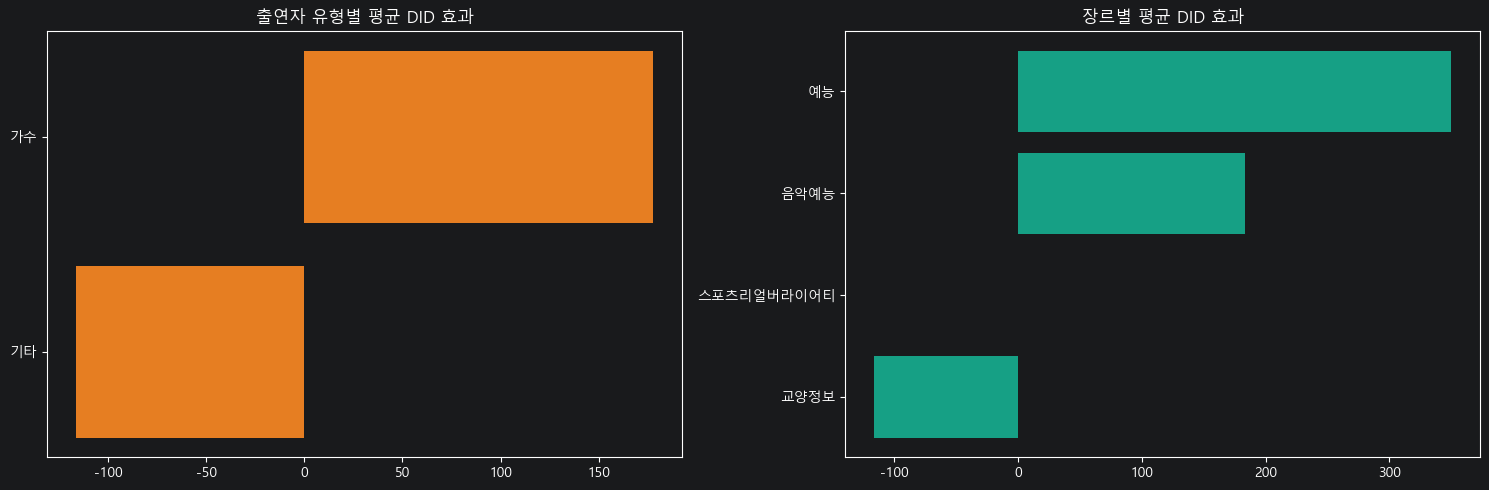

In [17]:
# 효과 + 특성 결합 (T맵 DID효과를 종속변수로)
meta = bdf[['name','genre','rating','budget_1000won']].rename(columns={'name':'프로그램명'})
meta = meta.merge(tmap_did[['프로그램명','DID_효과','DID_p']], on='프로그램명', how='left')
if len(cast_agg):
    meta = meta.merge(cast_agg, on='프로그램명', how='left')
print("=== 효과 × 특성 ===")
display(meta)

fig, axes = plt.subplots(1, 2, figsize=(15,5))
if '대표유형' in meta.columns and meta['대표유형'].notna().any():
    g = meta.dropna(subset=['DID_효과']).groupby('대표유형')['DID_효과'].mean().sort_values()
    axes[0].barh(g.index, g.values, color='#e67e22'); axes[0].set_title('출연자 유형별 평균 DID 효과')
gg = meta.dropna(subset=['DID_효과']).groupby('genre')['DID_효과'].mean().sort_values()
axes[1].barh(gg.index, gg.values, color='#16a085'); axes[1].set_title('장르별 평균 DID 효과')
plt.tight_layout(); plt.show()

In [18]:
# 메타 회귀 (표본 작음 → 탐색적)
reg = meta.dropna(subset=['DID_효과']).copy()
reg['rating'] = pd.to_numeric(reg['rating'], errors='coerce')
print(f"메타 회귀 표본: {len(reg)}건")
if len(reg) >= 4:
    for f in ['DID_효과 ~ rating', 'DID_효과 ~ 최고인지도', 'DID_효과 ~ C(genre)']:
        try:
            m = smf.ols(f, data=reg).fit()
            print(f"\n--- {f} --- R2={m.rsquared:.2f}"); print(m.params)
        except Exception as e: print(f, e)
else:
    print("표본<4 → 위 막대그래프 기술통계로 해석. 방향성만 참고.")

메타 회귀 표본: 4건

--- DID_효과 ~ rating --- R2=0.37
Intercept   -33.07
rating       47.55
dtype: float64

--- DID_효과 ~ 최고인지도 --- R2=0.00
Intercept   17.77
최고인지도       53.31
dtype: float64

--- DID_효과 ~ C(genre) --- R2=1.00
Intercept                -116.16
C(genre)[T.스포츠리얼버라이어티]    116.16
C(genre)[T.예능]            466.12
C(genre)[T.음악예능]          299.31
dtype: float64


## Part 6 — 다중결과 교차검증 + 종합 리포트

In [19]:
# 카드/T맵 효과를 한 매트릭스로 (방향 일치 여부)
matrix = bdf[['name','measurable']].rename(columns={'name':'프로그램명'})
matrix = matrix.merge(tmap_did[['프로그램명','DID_효과','평행추세_p']], on='프로그램명', how='left')
matrix = matrix.merge(tmap_ci[['프로그램명','CI_상대효과','CI_유의']], on='프로그램명', how='left')
matrix['T맵_방향'] = np.sign(matrix['DID_효과'])
matrix['평행추세_OK'] = matrix['평행추세_p'] > 0.05
print("="*70); print("  교차검증 매트릭스"); print("="*70)
display(matrix)
print("""
[해석]
- 평행추세_OK=False 인 방송: DID 가정 위반 → 효과 수치 신뢰 불가, 별도 주석 필요
- T맵 DID와 CausalImpact 방향이 일치하면 효과 신뢰도↑, 어긋나면 가정 점검
- 11월 4개 방송은 Part3 Staggered ATT(통합)로 해석 — 개별 분리 불가
- 출연자유형·장르 차이는 Part5 참고(표본 작아 탐색적)
""")
# 저장
matrix.to_csv(OUTPUT_DIR / 'cross_validation_matrix.csv', index=False, encoding='utf-8-sig')
print("저장:", OUTPUT_DIR / 'cross_validation_matrix.csv')

  교차검증 매트릭스


,프로그램명,measurable,DID_효과,평행추세_p,CI_상대효과,CI_유의,T맵_방향,평행추세_OK
0,전국노래자랑 아산시편,True,183.16,0.42,-9.13,True,1.00,True
1,전현무계획2,True,NaN,NaN,NaN,NaN,NaN,False
2,굿모닝 대한민국,True,-116.16,0.13,-58.96,True,-1.00,True
3,6시 내고향,True,NaN,NaN,NaN,NaN,NaN,False
4,박원숙의 같이삽시다 시즌3,True,349.96,0.68,162.00,True,1.00,True
5,뛰어야산다2,True,0.00,0.24,NaN,NaN,1.00,True
6,황제성의 황제파워,False,NaN,NaN,NaN,NaN,NaN,False



[해석]
- 평행추세_OK=False 인 방송: DID 가정 위반 → 효과 수치 신뢰 불가, 별도 주석 필요
- T맵 DID와 CausalImpact 방향이 일치하면 효과 신뢰도↑, 어긋나면 가정 점검
- 11월 4개 방송은 Part3 Staggered ATT(통합)로 해석 — 개별 분리 불가
- 출연자유형·장르 차이는 Part5 참고(표본 작아 탐색적)

저장: C:\Users\admin\Desktop\작업 폴더\01. work\02. 프로젝트\아산시\방송\02.분석결과\cross_validation_matrix.csv
